# Sample from the Normalizing Flows

## RealNVP

In [1]:
import torch
import matplotlib.pyplot as plt
import sys
import os

# Ensure local modules can be imported
sys.path.append(os.getcwd())
from unified_model import ModelFactory

In [2]:
# Example Configs
# Note: ndim must be large enough relative to seqfrac to avoid 0 dimension in hidden layers
realnvp_config = {
    'ndim': 32,
    'n_flow': 4,
    'affine': True,
    'seqfrac': 4
}

try:
    model = ModelFactory.create_model('realnvp', realnvp_config)
    print("RealNVP Model created successfully")
    # Dummy forward
    x = torch.randn(10, 32)
    z, logdet, _ = model.forward(x)
    print(f"Forward pass successful. z shape: {z.shape}, logdet shape: {logdet.shape}")
    x_recon = model.inverse(z)
    print(f"Inverse pass successful. x_recon shape: {x_recon.shape}")
except Exception as e:
    print(f"RealNVP Test Failed: {e}")
    import traceback
    traceback.print_exc()

RealNVP Model created successfully
Forward pass successful. z shape: torch.Size([10, 32]), logdet shape: torch.Size([10])
Inverse pass successful. x_recon shape: torch.Size([10, 32])


## Glow

In [3]:
# Glow Config
glow_config = {
    'in_channel': 3,
    'n_flow': 4,
    'n_block': 3,
    'affine': True,
    'conv_lu': True
}

try:
    # Glow expects image input (N, C, H, W)
    # Input size must be compatible with n_block downsampling (2^(n_block-1))
    # For n_block=3, divisible by 4. Let's use 32x32
    img_size = 32
    model = ModelFactory.create_model('glow', glow_config)
    print("Glow Model created successfully")
    
    x = torch.randn(2, 3, img_size, img_size)
    z_outs, logdet, _ = model.forward(x)
    print(f"Forward pass successful. logdet shape: {logdet.shape}")
    # z_outs is a list of tensors
    for i, z in enumerate(z_outs):
        print(f"z[{i}] shape: {z.shape}")
        
    x_recon = model.inverse(z_outs)
    print(f"Inverse pass successful. x_recon shape: {x_recon.shape}")
except Exception as e:
    print(f"Glow Test Failed: {e}")
    import traceback
    traceback.print_exc()

Glow Model created successfully
Forward pass successful. logdet shape: torch.Size([2])
z[0] shape: torch.Size([2, 6, 16, 16])
z[1] shape: torch.Size([2, 12, 8, 8])
z[2] shape: torch.Size([2, 48, 4, 4])
Inverse pass successful. x_recon shape: torch.Size([2, 3, 32, 32])


/Users/linyuxuan/workSpace/DeepMed-Imaging-Reconstruction/DPI/DPItorch/generative_model/glow_model.py:192: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  w_s = torch.from_numpy(w_s)


## Tarflow

In [4]:
# Tarflow Config
tarflow_config = {
    'in_channels': 3,
    'img_size': 32,
    'patch_size': 4,
    'channels': 64,
    'num_blocks': 4,
    'layers_per_block': 4,
    'nvp': True
}

try:
    model = ModelFactory.create_model('tarflow', tarflow_config)
    print("Tarflow Model created successfully")
    
    x = torch.randn(2, 3, 32, 32)
    z, logdets, _ = model.forward(x)
    print(f"Forward pass successful. z shape: {z.shape}, logdets shape: {logdets.shape}")
    
    x_recon = model.inverse(z)
    print(f"Inverse pass successful. x_recon shape: {x_recon.shape}")
except Exception as e:
    print(f"Tarflow Test Failed: {e}")
    import traceback
    traceback.print_exc()

Tarflow Model created successfully
Forward pass successful. z shape: torch.Size([2, 64, 48]), logdets shape: torch.Size([2])
Inverse pass successful. x_recon shape: torch.Size([2, 3, 32, 32])


## PET Model Sampling (PET 12000) with Refinement

Using device: mps


/var/folders/cn/bm0b2lrd3nx0l9plvqr1_tt80000gn/T/ipykernel_3721/822275950.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_locatio

Checkpoint loaded successfully


/Users/linyuxuan/anaconda3/envs/tarflow/lib/python3.10/site-packages/torch/nn/functional.py:5448: UserWarning: The operator 'aten::col2im' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:13.)
  return torch._C._nn.col2im(


Initial Sample generated. Shape: torch.Size([1, 1, 128, 128])
Running refinement...
Refinement complete.


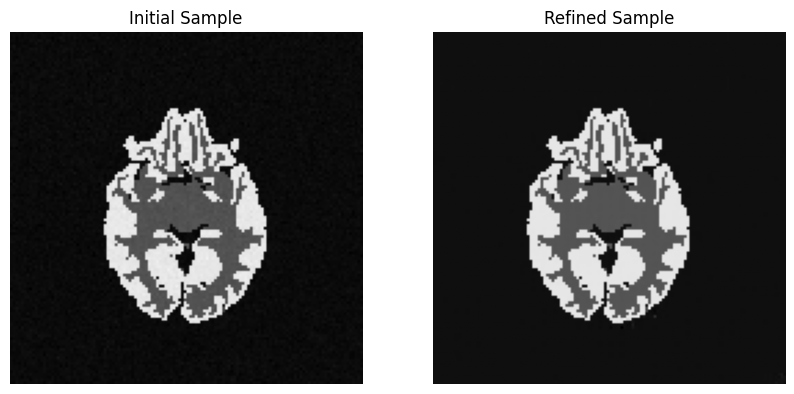

In [5]:
# Configuration based on filename: pet_12000_model_4_1024_8_8_0.01.pth
# noise_std=0.01 is critical for refinement step
pet_noise_std = 0.01
pet_config = {
    'in_channels': 1,       # PET is 1 channel
    'img_size': 128,        # Standard for PET in this repo
    'patch_size': 4,
    'channels': 1024,
    'num_blocks': 8,
    'layers_per_block': 8,
    'nvp': True
}

ckpt_path = 'data/tarflowPET/pet_12000_model_4_1024_8_8_0.01.pth'
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Using device: {device}")

try:
    if os.path.exists(ckpt_path):
        # 1. Create Model
        model_adapter = ModelFactory.create_model('tarflow', pet_config)
        model_adapter.to(device)
        
        # 2. Load Checkpoint
        state_dict = torch.load(ckpt_path, map_location=device)
        model_adapter.model.load_state_dict(state_dict)
        print("Checkpoint loaded successfully")
        
        # 3. Sample from Gaussian
        batch_size = 1
        num_patches = (pet_config['img_size'] // pet_config['patch_size']) ** 2
        latent_dim = pet_config['in_channels'] * (pet_config['patch_size'] ** 2)
        
        z = torch.randn(batch_size, num_patches, latent_dim, device=device)
        
        # Initial Sampling (Reverse Flow)
        with torch.no_grad():
            # Guidance can be used here if needed, e.g. guidance=1.0
            x_sample = model_adapter.inverse(z, guidance=0)

        print(f"Initial Sample generated. Shape: {x_sample.shape}")
        
        # Show Initial
        initial_img = x_sample[0].detach().cpu().permute(1, 2, 0).squeeze().numpy()
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(initial_img, cmap='gray')
        plt.title('Initial Sample')
        plt.axis('off')
        
        # 4. Refinement (Langevin Dynamics / Denoising)
        # Tarflow/Diffusion refinement step to maximize probability
        # Freeze model parameters
        for p in model_adapter.parameters():
            p.requires_grad = False
            
        # Learning rate for refinement
        # Based on heuristic from original notebook: batch * img_areas * channels * noise^2
        # Note: Original used sum of log_prob, so batch size scales it.
        lr = batch_size * (pet_config['img_size'] ** 2) * pet_config['in_channels'] * (pet_noise_std ** 2)
        
        # We need to optimize x
        x_sample = x_sample.detach().clone()
        x_sample.requires_grad = True
        
        print("Running refinement...")
        # One step is usually enough if noise is small, but loop is possible
        # Original notebook does one large step or iterative?
        # Original notebook: "loss = ...; grad = ...; x = x - lr * grad; samples = x"
        # It seems to do just one step in the notebook provided, but let's stick to that structure.
        
        # Forward pass to get latent and logdet for the *generated* image
        z_new, logdet_new, _ = model_adapter.forward(x_sample)
        
        # Calculate loss (Negative Log Likelihood / Energy)
        loss = model_adapter.get_loss(z_new, logdet_new)
        
        # Compute gradients w.r.t input image x
        grad = torch.autograd.grad(loss, [x_sample])[0]
        
        # Update image
        x_refined = x_sample.data - lr * grad
        
        print("Refinement complete.")
        
        # Show Refined
        refined_img = x_refined[0].cpu().permute(1, 2, 0).squeeze().numpy()
        plt.subplot(1, 2, 2)
        plt.imshow(refined_img, cmap='gray')
        plt.title('Refined Sample')
        plt.axis('off')
        plt.show()
        
    else:
        print(f"Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f"PET Sampling Failed: {e}")
    import traceback
    traceback.print_exc()